<a href="https://colab.research.google.com/github/Himanshu-Meshram/Projects/blob/main/Laptop_Price_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## Importing DATA SET
data = pd.read_csv('/content/laptop_data.csv')
data.head()
data.dtypes
data.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [ ]:
## Handling Missing Values.
data.isnull().sum()

## if null value occurs.
## data=data.dropna()

data
data.head()
data.shape

(1303, 12)

# **Data Cleaning**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
Company,0
TypeName,0
Ram,0
Gpu,0
OpSys,0
Weight,0
Price,0
ppi,0
Cpu brand,0


In [ ]:
data.duplicated().sum()

0

In [ ]:
data.drop(columns=["Unnamed: 0"],inplace=True)

In [ ]:
data.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,ppi,Cpu brand,HDD,SSD
0,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,226.983005,Intel Core i5,<NA>,<NA>
1,Apple,Ultrabook,8GB,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,127.677940,Intel Core i5,<NA>,<NA>
2,HP,Notebook,8GB,Intel HD Graphics 620,No OS,1.86kg,30636.0000,141.211998,Intel Core i5,<NA>,<NA>
3,Apple,Ultrabook,16GB,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,220.534624,Intel Core i7,<NA>,<NA>
4,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,226.983005,Intel Core i5,<NA>,<NA>


In [ ]:
data["Ram"]=data["Ram"].astype(str).str.replace("GB","")

In [ ]:
data["Weight"]=data["Weight"].str.replace("kg","")

In [ ]:
data["Ram"]=data["Ram"].astype('int')
data["Weight"]=data["Weight"].astype('float')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Company    1303 non-null   object 
 1   TypeName   1303 non-null   object 
 2   Ram        1303 non-null   int64  
 3   Gpu        1303 non-null   object 
 4   OpSys      1303 non-null   object 
 5   Weight     1303 non-null   float64
 6   Price      1303 non-null   float64
 7   ppi        1303 non-null   float64
 8   Cpu brand  1303 non-null   object 
 9   HDD        0 non-null      Int64  
 10  SSD        0 non-null      Int64  
dtypes: Int64(2), float64(3), int64(1), object(5)
memory usage: 114.7+ KB


# **Model**

<Axes: xlabel='Price', ylabel='Density'>

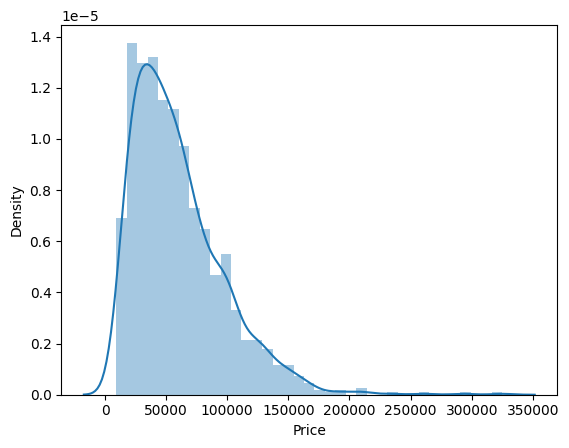

In [ ]:
sns.distplot(data["Price"])                             ## tiled LEFT side

<Axes: xlabel='Company'>

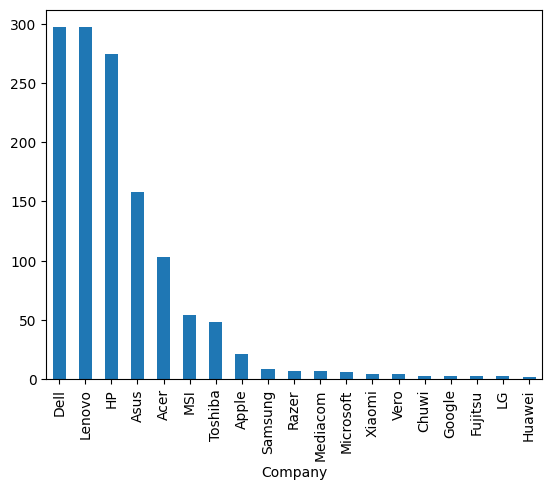

In [ ]:
data["Company"].value_counts().plot(kind="bar")
# plt.title("Company")

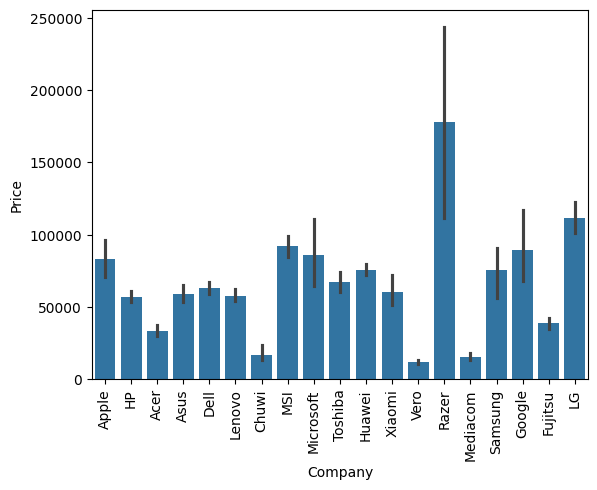

In [ ]:
sns.barplot(x=data["Company"],y=data["Price"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: xlabel='TypeName'>

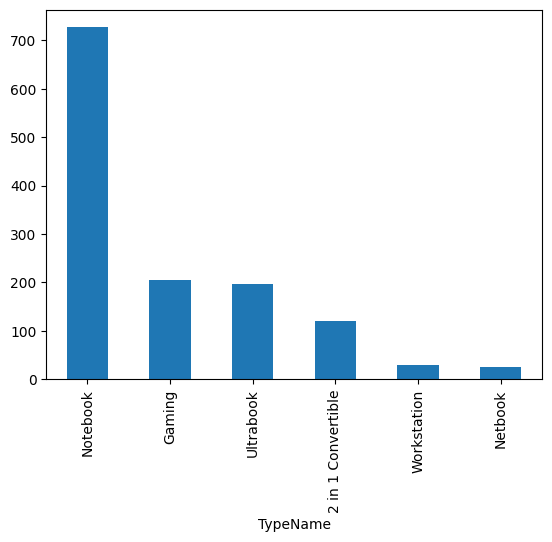

In [ ]:
data["TypeName"].value_counts().plot(kind="bar")

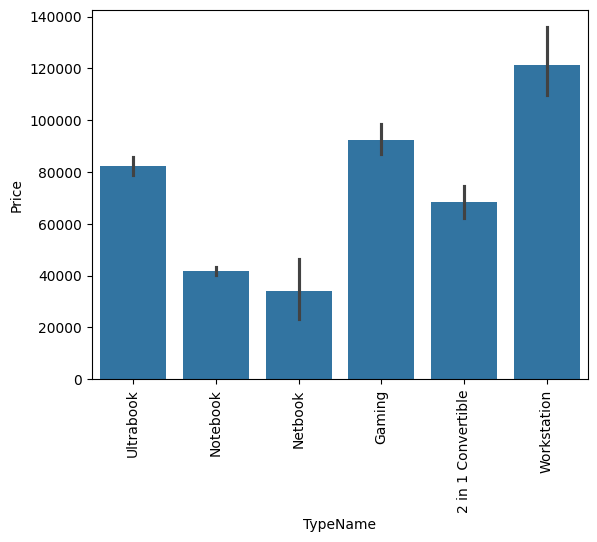

In [ ]:
sns.barplot(x=data["TypeName"],y=data["Price"])
plt.xticks(rotation="vertical")
plt.show()

<Axes: ylabel='Density'>

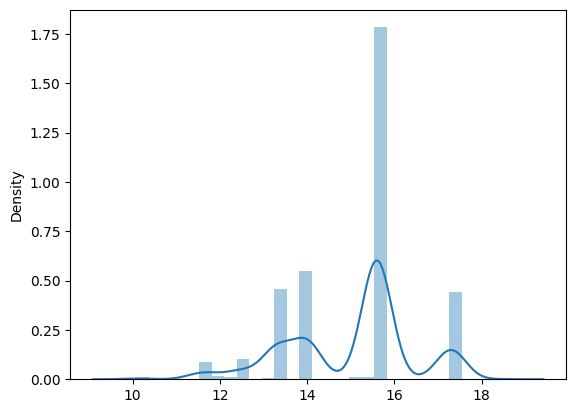

In [ ]:
sns.distplot(x=data["Inches"])

<Axes: xlabel='Inches', ylabel='Price'>

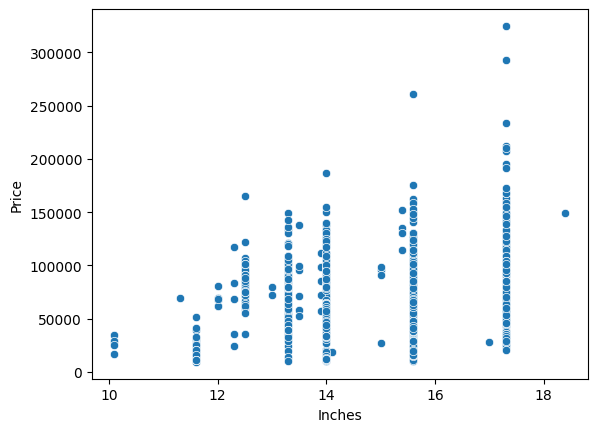

In [ ]:
sns.scatterplot(data=data,x="Inches",y="Price")

In [ ]:
data["ScreenResolution"].value_counts()

,count
ScreenResolution,
Full HD 1920x1080,507
1366x768,281
IPS Panel Full HD 1920x1080,230
IPS Panel Full HD / Touchscreen 1920x1080,53
Full HD / Touchscreen 1920x1080,47
1600x900,23
Touchscreen 1366x768,16
Quad HD+ / Touchscreen 3200x1800,15
IPS Panel 4K Ultra HD 3840x2160,12


In [ ]:
data["Touchscreen"]=data["ScreenResolution"].apply(lambda x:1 if "Touchscreen" in x else 0)
data.head(40)                         ## Checking

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0
5,5,Acer,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,21312.0000,0
6,6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,114017.6016,0
7,7,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,61735.5360,0
8,8,Asus,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,79653.6000,0
9,9,Acer,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,41025.6000,0


<Axes: xlabel='Touchscreen'>

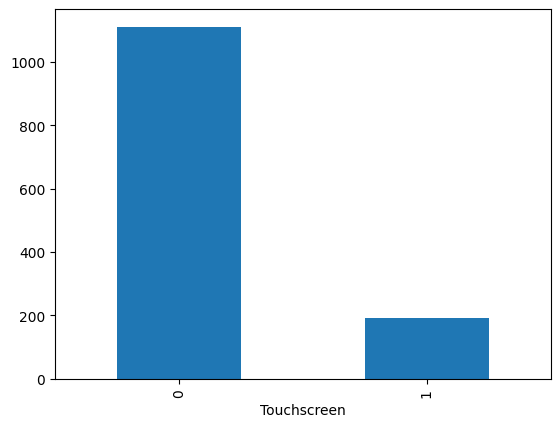

In [ ]:
data["Touchscreen"].value_counts().plot(kind="bar")

<Axes: xlabel='Touchscreen', ylabel='Price'>

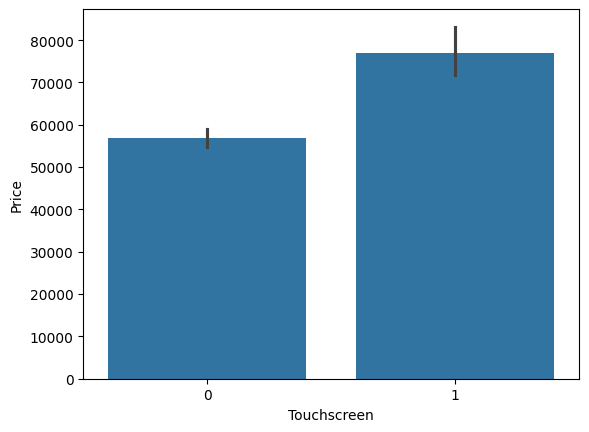

In [ ]:
sns.barplot(x=data["Touchscreen"],y=data["Price"])

In [ ]:
data["Ips"]=data["ScreenResolution"].apply(lambda x:1 if "IPS" in x else 0)
data.head()


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1


<Axes: xlabel='Ips', ylabel='Price'>

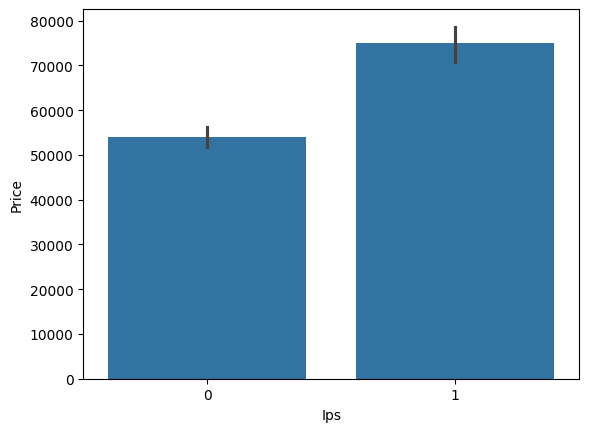

In [ ]:
sns.barplot(x=data["Ips"],y=data["Price"])


In [ ]:
data["ScreenResolution"].str.split("x")

,ScreenResolution
0,"[IPS Panel Retina Display 2560, 1600]"
1,"[1440, 900]"
2,"[Full HD 1920, 1080]"
3,"[IPS Panel Retina Display 2880, 1800]"
4,"[IPS Panel Retina Display 2560, 1600]"
...,...
1298,"[IPS Panel Full HD / Touchscreen 1920, 1080]"
1299,"[IPS Panel Quad HD+ / Touchscreen 3200, 1800]"
1300,"[1366, 768]"
1301,"[1366, 768]"


In [ ]:
temp = data["ScreenResolution"].str.split("x",n=1,expand=True)
data["X_res"]=temp[0]
data["Y_res"]=temp[1]
data.head()


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,1440,900
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,Full HD 1920,1080
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,IPS Panel Retina Display 2560,1600


In [ ]:
## replacing the string values
data['X_res'] = data['X_res'].str.replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])
data.head()


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,2560,1600
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,1440,900
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,1920,1080
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,2880,1800
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,2560,1600


In [ ]:
data["X_res"] = data["X_res"].astype("int")
data["Y_res"] = data["Y_res"].astype("int")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
 12  Touchscreen       1303 non-null   int64  
 13  Ips               1303 non-null   int64  
 14  X_res             1303 non-null   int64  
 15  Y_res             1303 non-null   int64  
dtypes: float64(2), int64(5), object(9)
memory 

In [ ]:
############################################## ERROR ###################################
# Select only numerical features for correlation calculation
numerical_features = data.select_dtypes(include=np.number).columns
corr = data[numerical_features].corr()

# Now you can access the correlation with 'Price'
price_correlation = corr['Price']

print(price_correlation)

Unnamed: 0     0.067984
Inches         0.068197
Price          1.000000
Touchscreen    0.191226
Ips            0.252208
X_res          0.556529
Y_res          0.552809
Name: Price, dtype: float64


In [ ]:
data['ppi'] = (((data['X_res']**2) + (data['Y_res']**2))**0.5/data['Inches']).astype('float')

In [ ]:
### data.corr()['Price']

############################################## ERROR ###################################
# Select only numerical features for correlation calculation
numerical_features = data.select_dtypes(include=np.number).columns
corr = data[numerical_features].corr()

# Now you can access the correlation with 'Price'
price_correlation = corr['Price']

print(price_correlation)

Unnamed: 0     0.067984
Inches         0.068197
Price          1.000000
Touchscreen    0.191226
Ips            0.252208
X_res          0.556529
Y_res          0.552809
ppi            0.473487
Name: Price, dtype: float64


In [ ]:
data.drop(columns=["ScreenResolution","X_res","Y_res","Inches"],inplace=True)
data.head()


,Unnamed: 0,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi
0,0,Apple,Ultrabook,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005
1,1,Apple,Ultrabook,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940
2,2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998
3,3,Apple,Ultrabook,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624
4,4,Apple,Ultrabook,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005


In [ ]:
data["Cpu"].value_counts()


,count
Cpu,
Intel Core i5 7200U 2.5GHz,190
Intel Core i7 7700HQ 2.8GHz,146
Intel Core i7 7500U 2.7GHz,134
Intel Core i7 8550U 1.8GHz,73
Intel Core i5 8250U 1.6GHz,72
...,...
Intel Core M M3-6Y30 0.9GHz,1
AMD A9-Series 9420 2.9GHz,1
Intel Core i3 6006U 2.2GHz,1


In [ ]:
data['Cpu Name'] = data['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))
data.head()

,Unnamed: 0,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name
0,0,Apple,Ultrabook,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5
1,1,Apple,Ultrabook,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5
2,2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5
3,3,Apple,Ultrabook,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7
4,4,Apple,Ultrabook,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5


In [ ]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [ ]:
data['Cpu brand'] = data['Cpu Name'].apply(fetch_processor)
data.head()


,Unnamed: 0,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu Name,Cpu brand
0,0,Apple,Ultrabook,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,Intel Core i5
1,1,Apple,Ultrabook,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,Intel Core i5
2,2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,Intel Core i5
3,3,Apple,Ultrabook,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,Intel Core i7
4,4,Apple,Ultrabook,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,Intel Core i5


<Axes: xlabel='Cpu brand'>

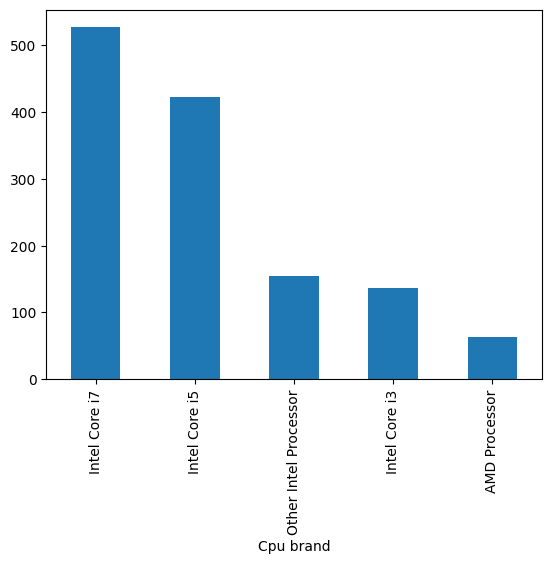

In [ ]:
data['Cpu brand'].value_counts().plot(kind='bar')

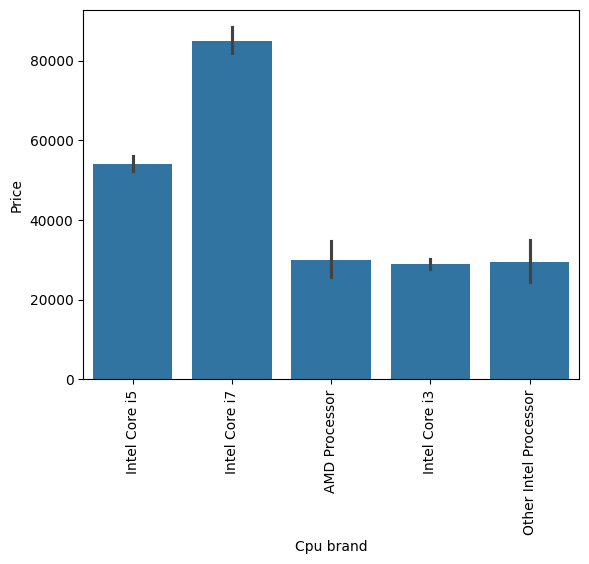

In [ ]:
sns.barplot(x=data['Cpu brand'],y=data['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
data.drop(columns=['Cpu','Cpu Name'],inplace=True)
data.head()

,Unnamed: 0,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand
0,0,Apple,Ultrabook,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5
1,1,Apple,Ultrabook,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5
2,2,HP,Notebook,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5
3,3,Apple,Ultrabook,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7
4,4,Apple,Ultrabook,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5


<Axes: xlabel='Ram'>

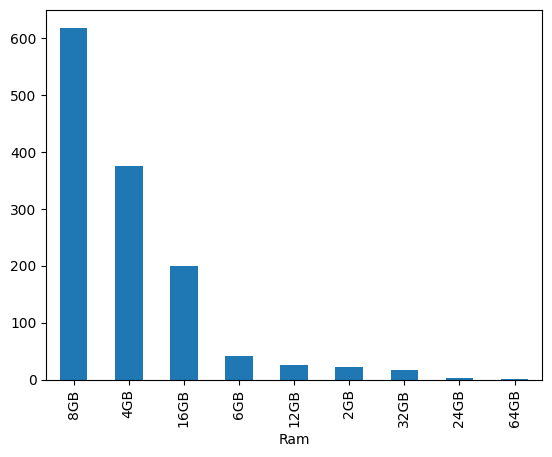

In [ ]:
data['Ram'].value_counts().plot(kind='bar')


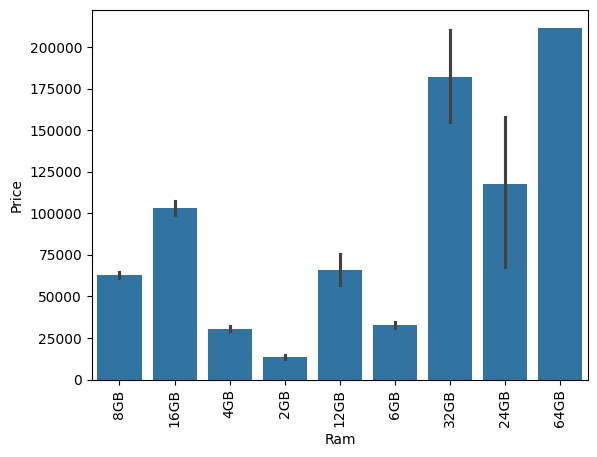

In [ ]:
sns.barplot(x=data['Ram'],y=data['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
data['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [ ]:
data['Memory'] = data['Memory'].astype(str).replace('\.0', '', regex=True)
data["Memory"] = data["Memory"].str.replace('GB', '')
data["Memory"] = data["Memory"].str.replace('TB', '000')
new = data["Memory"].str.split("+", n = 1, expand = True)

data["first"]= new[0]
data["first"]=data["first"].str.strip()

data["second"]= new[1]

data["Layer1HDD"] = data["first"].apply(lambda x: 1 if "HDD" in x else 0)
data["Layer1SSD"] = data["first"].apply(lambda x: 1 if "SSD" in x else 0)
data["Layer1Hybrid"] = data["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
data["Layer1Flash_Storage"] = data["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

data['first'] = data['first'].str.replace(r'\D', '')

data["second"].fillna("0", inplace = True)

data["Layer2HDD"] = data["second"].apply(lambda x: 1 if "HDD" in x else 0)
data["Layer2SSD"] = data["second"].apply(lambda x: 1 if "SSD" in x else 0)
data["Layer2Hybrid"] = data["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
data["Layer2Flash_Storage"] = data["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

data['second'] = data['second'].str.replace(r'\D', '')

data['first'] = pd.to_numeric(data['first'], errors='coerce').astype('Int64') #changed this line
data['second'] = pd.to_numeric(data['second'], errors='coerce').astype('Int64') #changed this line as well

data["HDD"]=(data["first"]*data["Layer1HDD"]+data["second"]*data["Layer2HDD"])
data["SSD"]=(data["first"]*data["Layer1SSD"]+data["second"]*data["Layer2SSD"])
data["Hybrid"]=(data["first"]*data["Layer1Hybrid"]+data["second"]*data["Layer2Hybrid"])
data["Flash_Storage"]=(data["first"]*data["Layer1Flash_Storage"]+data["second"]*data["Layer2Flash_Storage"])

data.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

data.head()


,Unnamed: 0,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,0,Apple,Ultrabook,8GB,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,<NA>,<NA>,<NA>,<NA>
1,1,Apple,Ultrabook,8GB,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,<NA>,<NA>,<NA>,<NA>
2,2,HP,Notebook,8GB,256 SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,<NA>,<NA>,<NA>,<NA>
3,3,Apple,Ultrabook,16GB,512 SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,<NA>,<NA>,<NA>,<NA>
4,4,Apple,Ultrabook,8GB,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,<NA>,<NA>,<NA>,<NA>


In [ ]:
data.drop(columns=['Memory'],inplace=True)


In [ ]:
data.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
data.head()


,Unnamed: 0,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD
0,0,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,<NA>,<NA>
1,1,Apple,Ultrabook,8GB,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,<NA>,<NA>
2,2,HP,Notebook,8GB,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,<NA>,<NA>
3,3,Apple,Ultrabook,16GB,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,<NA>,<NA>
4,4,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,<NA>,<NA>


In [ ]:
data['Gpu'].value_counts()


,count
Gpu,
Intel HD Graphics 620,281
Intel HD Graphics 520,185
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
...,...
AMD Radeon R5 520,1
AMD Radeon R7,1
Intel HD Graphics 540,1


In [ ]:
data['Gpu brand'] = data['Gpu'].apply(lambda x:x.split()[0])
data.head()


,Unnamed: 0,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,0,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel
1,1,Apple,Ultrabook,8GB,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,<NA>,<NA>,Intel
2,2,HP,Notebook,8GB,Intel HD Graphics 620,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,<NA>,<NA>,Intel
3,3,Apple,Ultrabook,16GB,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,<NA>,<NA>,AMD
4,4,Apple,Ultrabook,8GB,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel


In [ ]:
data['Gpu brand'].value_counts()


,count
Gpu brand,
Intel,722
Nvidia,400
AMD,180
ARM,1


In [ ]:
data = data[data['Gpu brand'] != 'ARM']


In [ ]:
data['Gpu brand'].value_counts()

,count
Gpu brand,
Intel,722
Nvidia,400
AMD,180


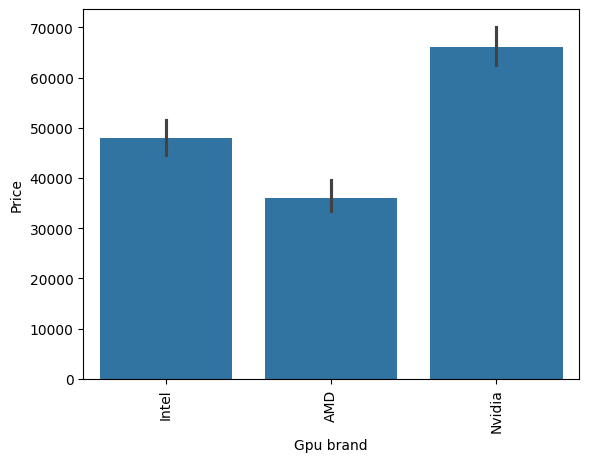

In [ ]:
sns.barplot(x=data['Gpu brand'],y=data['Price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
data.drop(columns=['Gpu'],inplace=True)
data.head()

,Unnamed: 0,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand
0,0,Apple,Ultrabook,8GB,macOS,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel
1,1,Apple,Ultrabook,8GB,macOS,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,<NA>,<NA>,Intel
2,2,HP,Notebook,8GB,No OS,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,<NA>,<NA>,Intel
3,3,Apple,Ultrabook,16GB,macOS,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,<NA>,<NA>,AMD
4,4,Apple,Ultrabook,8GB,macOS,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel


In [ ]:
data['OpSys'].value_counts()

,count
OpSys,
Windows 10,1072
No OS,66
Linux,62
Windows 7,45
Chrome OS,26
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


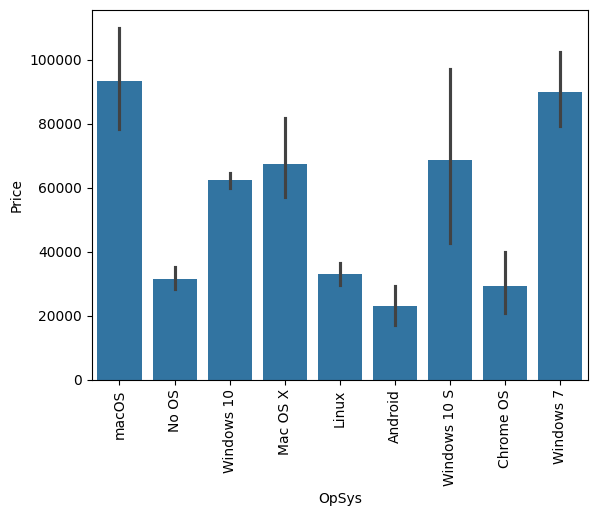

In [ ]:
sns.barplot(x=data['OpSys'],y=data['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [ ]:
data['os'] = data['OpSys'].apply(cat_os)

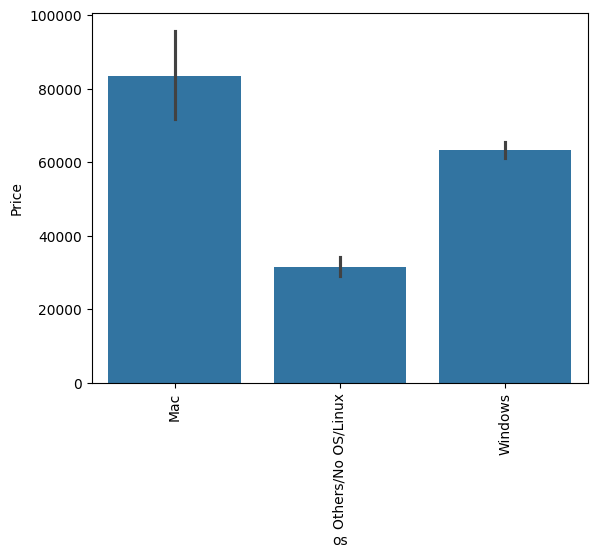

In [ ]:
sns.barplot(x=data['os'],y=data['Price'])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
data.drop(columns=['OpSys'],inplace=True)
data.head()

,Unnamed: 0,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,0,Apple,Ultrabook,8GB,1.37kg,71378.6832,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel,Mac
1,1,Apple,Ultrabook,8GB,1.34kg,47895.5232,0,0,127.677940,Intel Core i5,<NA>,<NA>,Intel,Mac
2,2,HP,Notebook,8GB,1.86kg,30636.0000,0,0,141.211998,Intel Core i5,<NA>,<NA>,Intel,Others/No OS/Linux
3,3,Apple,Ultrabook,16GB,1.83kg,135195.3360,0,1,220.534624,Intel Core i7,<NA>,<NA>,AMD,Mac
4,4,Apple,Ultrabook,8GB,1.37kg,96095.8080,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel,Mac


<Axes: xlabel='Weight', ylabel='Density'>

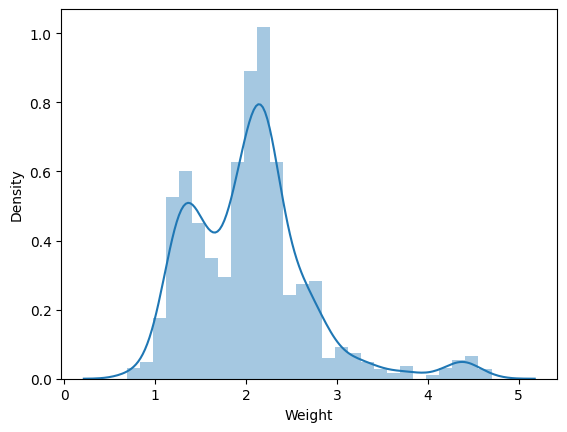

In [ ]:
sns.distplot(data['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

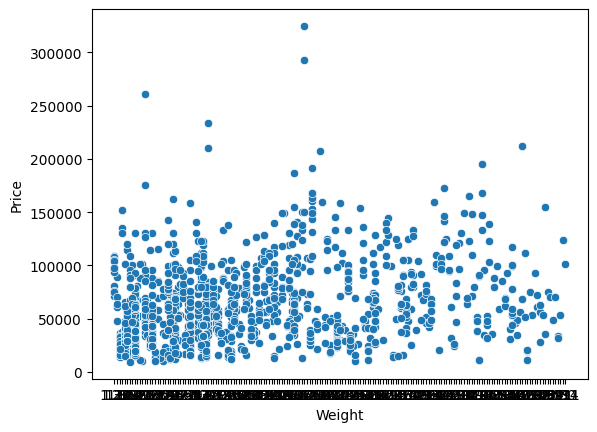

In [ ]:
sns.scatterplot(x=data['Weight'],y=data['Price'])

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1302 non-null   int64  
 1   Company      1302 non-null   object 
 2   TypeName     1302 non-null   object 
 3   Ram          1302 non-null   object 
 4   Weight       1302 non-null   object 
 5   Price        1302 non-null   float64
 6   Touchscreen  1302 non-null   int64  
 7   Ips          1302 non-null   int64  
 8   ppi          1302 non-null   float64
 9   Cpu brand    1302 non-null   object 
 10  HDD          0 non-null      Int64  
 11  SSD          0 non-null      Int64  
 12  Gpu brand    1302 non-null   object 
 13  os           1302 non-null   object 
dtypes: Int64(2), float64(2), int64(3), object(7)
memory usage: 155.1+ KB


<Axes: xlabel='Price', ylabel='Density'>

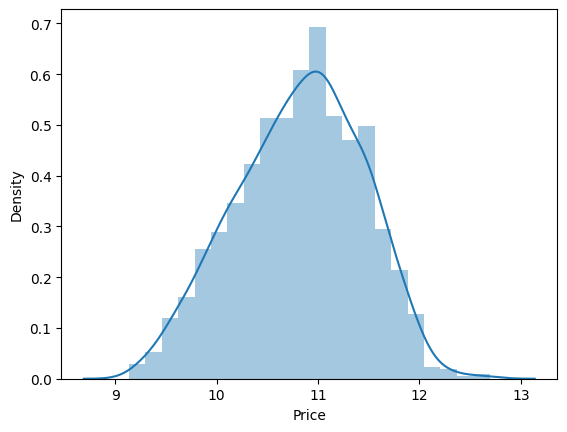

In [ ]:
sns.distplot(np.log(data['Price']))

In [ ]:
X = data.drop(columns=['Price'])
y = np.log(data['Price'])

In [ ]:
X

,Unnamed: 0,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu brand,HDD,SSD,Gpu brand,os
0,0,Apple,Ultrabook,8GB,1.37,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel,Mac
1,1,Apple,Ultrabook,8GB,1.34,0,0,127.677940,Intel Core i5,<NA>,<NA>,Intel,Mac
2,2,HP,Notebook,8GB,1.86,0,0,141.211998,Intel Core i5,<NA>,<NA>,Intel,Others/No OS/Linux
3,3,Apple,Ultrabook,16GB,1.83,0,1,220.534624,Intel Core i7,<NA>,<NA>,AMD,Mac
4,4,Apple,Ultrabook,8GB,1.37,0,1,226.983005,Intel Core i5,<NA>,<NA>,Intel,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,4GB,1.8,1,1,157.350512,Intel Core i7,<NA>,<NA>,Intel,Windows
1299,1299,Lenovo,2 in 1 Convertible,16GB,1.3,1,1,276.053530,Intel Core i7,<NA>,<NA>,Intel,Windows
1300,1300,Lenovo,Notebook,2GB,1.5,0,0,111.935204,Other Intel Processor,<NA>,<NA>,Intel,Windows
1301,1301,HP,Notebook,6GB,2.19,0,0,100.454670,Intel Core i7,<NA>,<NA>,AMD,Windows


In [ ]:
y

,Price
0,11.175755
1,10.776777
2,10.329931
3,11.814476
4,11.473101
...,...
1298,10.433899
1299,11.288115
1300,9.409283
1301,10.614129


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.15,random_state=2)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

**LINEAR REGRESSION**

In [ ]:
# step1 = ColumnTransformer(transformers=[
#     ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,7,10,11])
# ],remainder='passthrough')

# step2 = Lasso(alpha=0.001)

# pipe = Pipeline([
#     ('step1',step1),
#     ('step2',step2)
# ])

# pipe.fit(X_train,y_train)

# y_pred = pipe.predict(X_test)

# print('R2 score',r2_score(y_test,y_pred))
# print('MAE',mean_absolute_error(y_test,y_pred))

ValueError: The output of the 'remainder' transformer for column 'HDD' has dtype Int64 and uses pandas.NA to represent null values. Storing this output in a numpy array can cause errors in downstream scikit-learn estimators, and inefficiencies. To avoid this problem you can (i) store the output in a pandas DataFrame by using ColumnTransformer.set_output(transform='pandas') or (ii) modify the input data or the 'remainder' transformer to avoid the presence of pandas.NA (for example by using pandas.DataFrame.astype).

In [ ]:
# step1 = ColumnTransformer(transformers=[
#     ('col_tnf',OneHotEncoder(sparse=False,drop='first'),[0,1,7,10,11])
# ],remainder='passthrough')

# step2 = KNeighborsRegressor(n_neighbors=3)

# pipe = Pipeline([
#     ('step1',step1),
#     ('step2',step2)
# ])

# pipe.fit(X_train,y_train)

# y_pred = pipe.predict(X_test)

# print('R2 score',r2_score(y_test,y_pred))
# print('MAE',mean_absolute_error(y_test,y_pred))

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'